# Phase 5 — Novel Approaches on the 17-Patient Test Set

**Novel approaches evaluated here** (all one-change retrains on top of the `run_v7_crop_sequence` base — same starting checkpoint, same architecture, same cropped data, only one thing changed per run):

| Code | Approach |
|---|---|
| **A3-up** | Slice-position weighted loss — end slices count up to 2x |
| **A3-down** | Slice-position weighted loss — end slices count as little as 0.3x (Check 4A's predicted winner) |
| **E1** | Slice position as a 4th input channel (zero-init verified) |
| **E2** | Slice position via FiLM gating at the ConvLSTM bottleneck (zero-init verified) |
| **D** | Position-conditioned shape (area) prior |
| **G2** | Region-darker-than-rim loss, gated by a measured pre-check |

Baseline for every comparison: `run_v7_crop_sequence`, 17pt test Dice **0.8057**, val Dice **0.80674** — itself the first Phase 4 result to clear the ±0.0226 noise floor (`docs/phase4_results.md`, step 15).

**Touches the 17-patient test set** — same explicit-exception basis as `analysis_phase4_17patients.ipynb`.

**Prerequisite (run on BigRed first):** `finetune_a3_up.sh`, `finetune_a3_down.sh`, `finetune_g2.sh`, `finetune_e1.sh`, `finetune_e2.sh`, `finetune_d.sh` (training), then `infer_g2_17pt_test.sh` + `infer_experiments_batch.sh` (17pt inference — A3/G2 reuse `infer_sequence_v3_crop.py` unchanged; E1/E2 need their own position-aware inference scripts, `infer_sequence_v3_crop_pos.py` / `infer_sequence_v3_crop_film.py`). Then scp `results/real_pd_predictions_{a3_up,a3_down,g2_rim,e1_pos,e2_film}_17pt/` down into this repo's `results/`.

Section 1 = fresh 17-patient test Dice.
Section 2 = the 2 real-val patients' validation Dice, from each run's `history.csv`.
Section 2b = fake-PD validation Dice per patient, where each run's `fake_val_per_slice_dice.csv` exists (may not exist yet for these runs — see caveat there).
Section 3 = comparative ranking against the crop+sequence baseline and the noise floor.

In [1]:
import os
import glob
import re
import csv

import numpy as np
import pandas as pd
import nibabel as nib
import SimpleITK as sitk
import matplotlib.pyplot as plt
from scipy.ndimage import zoom

In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────
BASE = "/Users/anshikabajpai/Desktop/github/RegGAN_domain_adaptation_v2"
RES  = f"{BASE}/results"
RUNS = f"{BASE}/segmentation_runs"

GT_DIR_D1  = "/Users/anshikabajpai/Desktop/AImed-lab/SEGMENTATIONS/PD-segmentations-final"
GT_DIR_NEW = "/Users/anshikabajpai/Downloads/final-segmentations"   # NOT "segmentations" -- landmine

# label -> (prediction dir for 17pt inference, run dir holding history.csv for val Dice)
RUNS_INFO = {
    "crop+sequence (baseline)": (f"{RES}/real_pd_predictions_crop_sequence_17pt", f"{RUNS}/run_v7_crop_sequence"),
    "A3-up (end slices x2)":    (f"{RES}/real_pd_predictions_a3_up_17pt",         f"{RUNS}/run_a3_up_seed42"),
    "A3-down (end slices x0.3)":(f"{RES}/real_pd_predictions_a3_down_17pt",       f"{RUNS}/run_a3_down_seed42"),
    "E1 (position channel)":    (f"{RES}/real_pd_predictions_e1_pos_17pt",        f"{RUNS}/run_e1_pos_seed42"),
    "E2 (FiLM gating)":         (f"{RES}/real_pd_predictions_e2_film_17pt",       f"{RUNS}/run_e2_film_seed42"),
    "G2 (rim-darkness loss)":   (f"{RES}/real_pd_predictions_g2_rim_17pt",        f"{RUNS}/run_g2_rim_seed42"),
    "D (shape prior)":          (f"{RES}/real_pd_predictions_d_shape_17pt",      f"{RUNS}/run_d_shape_lamauto_seed42"),
}
# D: retrained 2026-09-22 with the lam-calibration fix. The first attempt
# collapsed to all-background on a hardcoded lam=0.01; calibration chose
# lam=1.50e-06 instead (~6700x smaller). Training is healthy, but area_frac
# decays 0.0305 -> 0.0004 within 3 epochs, so the shape-prior term is
# effectively inactive after the start -- read D as close to a no-op.
#
# CAVEAT on A3-up / A3-down ABOVE: these crop+sequence A3 runs carry a CE
# normalisation bug (per-sample CE divided by pixel count instead of by the
# summed class weights, making it ~8.3x too small and shifting the CE:Dice
# balance). They are NOT clean position-weighting results. The fix lives in
# segmentation/finetune_meniscus_v7_replica_a3_v2.py, plain-2.5D arm only.
# NOTE: A3/G2 share one inference script (infer_sequence_v3_crop.py) because
# they only change the LOSS, not the architecture -- checkpoint-agnostic.
# E1/E2 needed their own inference scripts (crop_pos / crop_film) since they
# also change the model's forward() signature (extra `pos` argument).

D1_PATIENTS = [
    "AC0D5A4D78B628", "AC0D7BF72F7712", "AC0D3459553205", "AC14D3737C0482",
    "AC19E7C19827FF", "AC149BC218E75C", "AC111633B463BB", "AC13300201B926",
    "AC12026D14291F", "AC13637DA25399",
]
NEW_PATIENTS = [
    "AC000550763509", "AC005135D3495B", "AC04433E37DB66", "AC056ADCE8BE28",
    "AC07607B9E5295", "AC0D1A9818A6FC", "AC0F11041F5180",
]
ALL_PATIENTS = D1_PATIENTS + NEW_PATIENTS

# the 2 real-PD VALIDATION patients (never in the 17pt test set)
VAL_PATIENTS = ["AC0CE315D5758B", "AC0CEE9C24F2B7"]

print(f"Test set: {len(ALL_PATIENTS)} patients (D1={len(D1_PATIENTS)}, new={len(NEW_PATIENTS)})")
print(f"Val set : {len(VAL_PATIENTS)} patients (never overlaps the test set)")

Test set: 17 patients (D1=10, new=7)
Val set : 2 patients (never overlaps the test set)


## Helpers — same convention as `analysis_phase4_17patients.ipynb`

In [3]:
def get_pid(fname):
    m = re.match(r"(AC[A-F0-9]+)", os.path.basename(fname), re.IGNORECASE)
    return m.group(1) if m else None

def patients_in_dir(directory):
    files = glob.glob(os.path.join(directory, "*.nii.gz"))
    return {get_pid(f): f for f in files if get_pid(f)}

def load_vol(path):
    return np.asarray(nib.load(path).get_fdata())

def load_nrrd_binary(path):
    """Verbatim convention from analysis_abstract_17patients.ipynb / compare_stack_variants.py."""
    img = sitk.ReadImage(path)
    arr = sitk.GetArrayFromImage(img)
    if arr.ndim == 4:
        arr = (arr.max(axis=0) > 0).astype(np.uint8)
        out = sitk.GetImageFromArray(arr)
        try:
            comp = sitk.VectorIndexSelectionCast(img, 0)
            out.CopyInformation(comp)
        except Exception:
            out.SetSpacing(img.GetSpacing()[:3]); out.SetOrigin(img.GetOrigin()[:3])
            out.SetDirection(img.GetDirection()[:9])
    else:
        arr = (arr > 0).astype(np.uint8)
        out = sitk.GetImageFromArray(arr)
        out.CopyInformation(img)
    try:
        out = sitk.DICOMOrient(out, "RAS")
    except Exception:
        pass
    sp  = out.GetSpacing()
    arr = sitk.GetArrayFromImage(out).astype(np.float32).transpose(2, 1, 0)
    fa  = float(sp[1]) / min(sp[1], sp[2])
    fs  = float(sp[2]) / min(sp[1], sp[2])
    if abs(fa - 1.0) > 0.02 or abs(fs - 1.0) > 0.02:
        arr = zoom(arr, (1.0, fa, fs), order=0)
    _, n_A, n_S = arr.shape
    if n_A != 384 or n_S != 384:
        arr = zoom(arr, (1.0, 384 / n_A, 384 / n_S), order=0)
    return (arr > 0.5).astype(bool)

def merge_meniscus(pred):
    return (pred > 0).astype(bool)

def dice_score(pred_bin, gt_bin):
    if pred_bin.shape != gt_bin.shape:
        raise ValueError(f"shape mismatch: pred {pred_bin.shape} vs gt {gt_bin.shape} "
                         f"-- refusing to silently resample, fix the source")
    inter = (pred_bin & gt_bin).sum()
    denom = pred_bin.sum() + gt_bin.sum()
    return float(2 * inter / denom) if denom > 0 else 1.0

## Section 1 — 17-patient test Dice (fresh inference)

In [4]:
gt_masks = {}
for pid in ALL_PATIENTS:
    hits = (glob.glob(os.path.join(GT_DIR_D1,  f"{pid}*.seg.nrrd")) or
            glob.glob(os.path.join(GT_DIR_NEW, f"{pid}*.seg.nrrd")))
    if hits:
        gt_masks[pid] = hits[0]
    else:
        print(f"WARNING: No GT for {pid}")
print(f"GT masks found: {len(gt_masks)}/{len(ALL_PATIENTS)}")

preds_by_run = {}
for label, (pred_dir, _) in RUNS_INFO.items():
    d = patients_in_dir(pred_dir) if os.path.isdir(pred_dir) else {}
    preds_by_run[label] = d
    status = f"{len(d)}/{len(ALL_PATIENTS)}" if d else "NOT FOUND -- pull results down / run inference first"
    print(f"{label:<28}: {status}")

GT masks found: 17/17
crop+sequence (baseline)    : 17/17
A3-up (end slices x2)       : 17/17
A3-down (end slices x0.3)   : 17/17
E1 (position channel)       : 17/17
E2 (FiLM gating)            : 17/17
G2 (rim-darkness loss)      : 17/17
D (shape prior)             : 17/17


In [5]:
rows = []
for pid in ALL_PATIENTS:
    if pid not in gt_masks:
        continue
    gt_bin = load_nrrd_binary(gt_masks[pid])
    row = {"patient": pid, "cohort": "D1" if pid in D1_PATIENTS else "new"}
    for label, preds in preds_by_run.items():
        if pid in preds:
            pred = load_vol(preds[pid])
            row[label] = dice_score(merge_meniscus(pred), gt_bin)
        else:
            row[label] = float("nan")
    rows.append(row)

df = pd.DataFrame(rows)
means = df[list(RUNS_INFO.keys())].mean()
print("MEAN 17pt Dice per run:")
print(means.round(4).to_string())
df

MEAN 17pt Dice per run:
crop+sequence (baseline)     0.8057
A3-up (end slices x2)        0.8006
A3-down (end slices x0.3)    0.7905
E1 (position channel)        0.7880
E2 (FiLM gating)             0.8016
G2 (rim-darkness loss)       0.8022
D (shape prior)              0.7997


,patient,cohort,crop+sequence (baseline),A3-up (end slices x2),A3-down (end slices x0.3),E1 (position channel),E2 (FiLM gating),G2 (rim-darkness loss),D (shape prior)
0,AC0D5A4D78B628,D1,0.802140,0.812225,0.789736,0.814470,0.813128,0.778862,0.790924
1,AC0D7BF72F7712,D1,0.814227,0.820280,0.809041,0.753561,0.821524,0.792264,0.820346
2,AC0D3459553205,D1,0.786479,0.762509,0.751015,0.755638,0.770302,0.780821,0.770176
3,AC14D3737C0482,D1,0.812827,0.821276,0.810378,0.769242,0.803892,0.799482,0.828848
4,AC19E7C19827FF,D1,0.840926,0.839965,0.829266,0.840800,0.843013,0.844004,0.841394
5,AC149BC218E75C,D1,0.812214,0.836121,0.853381,0.834711,0.842837,0.821429,0.813624
6,AC111633B463BB,D1,0.850304,0.848041,0.829145,0.836261,0.845156,0.857816,0.845052
7,AC13300201B926,D1,0.767615,0.775413,0.764180,0.779537,0.780951,0.804860,0.762731
8,AC12026D14291F,D1,0.788704,0.795513,0.753380,0.750552,0.768323,0.800670,0.780596
9,AC13637DA25399,D1,0.835058,0.840011,0.817779,0.817198,0.840588,0.842088,0.837356


In [6]:
# Control check: crop+sequence's 17pt inference here should reproduce its
# already-known result (0.8057) before trusting the novel-approach columns.
baseline_label = "crop+sequence (baseline)"
if baseline_label in means.index and not np.isnan(means[baseline_label]):
    print(f"{baseline_label} 17pt mean: {means[baseline_label]:.4f}  (reference: 0.8057, docs/phase4_results.md step 15)")

crop+sequence (baseline) 17pt mean: 0.8057  (reference: 0.8057, docs/phase4_results.md step 15)


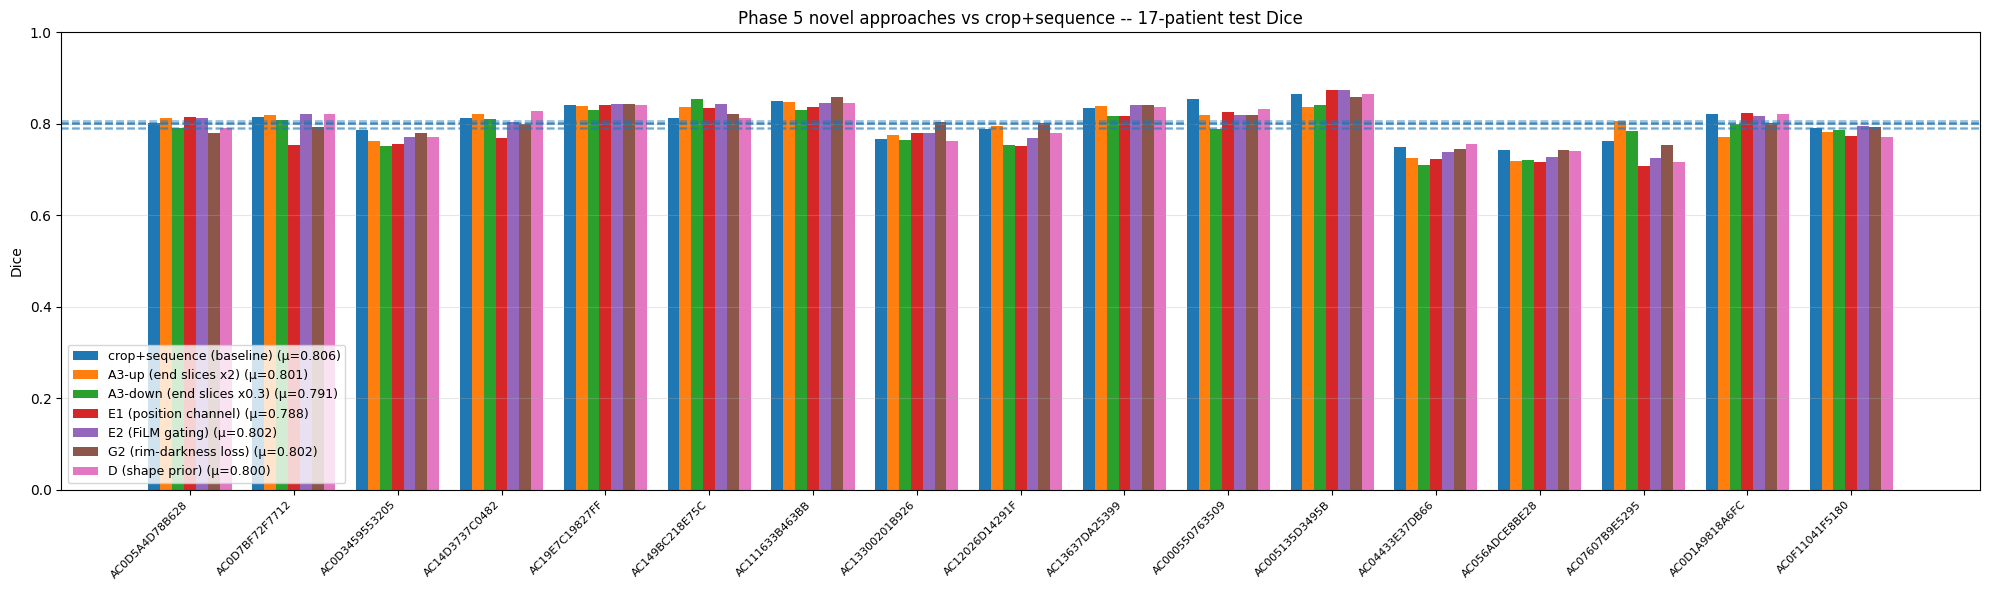

In [7]:
fig, ax = plt.subplots(figsize=(20, 6))
x = np.arange(len(df))
labels = [l for l in RUNS_INFO if df[l].notna().any()]
w = 0.8 / max(len(labels), 1)
for i, label in enumerate(labels):
    ax.bar(x + i * w, df[label], w, label=f"{label} (μ={means[label]:.3f})")
    ax.axhline(means[label], linestyle="--", alpha=0.4)
ax.set_xticks(x + w * (len(labels) - 1) / 2)
ax.set_xticklabels(df["patient"], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Dice"); ax.set_ylim(0, 1.0)
ax.set_title("Phase 5 novel approaches vs crop+sequence -- 17-patient test Dice")
ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

## Section 2 — Validation Dice (2 real-val patients, from `history.csv`)

No inference needed here -- every run already logs per-patient validation Dice at its own best epoch. Each Phase 5 run's `history.csv` also carries an extra trailing column specific to that experiment (`pos_wnorm` for E1/E2, `rim_frac`/`rim_tr` for G2, `area_frac`/`area_tr` for D) -- `best_epoch_val_dice()` below only reads the columns it needs, so those extras are ignored safely, not an error.

In [8]:
def best_epoch_val_dice(history_path):
    """Returns (best_epoch, dice_real_va, {pid: dice_va_pid}, dice_real_tr, gap) at
    the epoch dice_real_va is maximized -- same criterion ckpt_best.pth uses.
    Extra trailing columns specific to one experiment (pos_wnorm, rim_frac,
    area_frac, ...) are present in some history.csv files and simply ignored."""
    if not os.path.exists(history_path):
        return None
    rows = list(csv.DictReader(open(history_path)))
    best = max(rows, key=lambda r: float(r["dice_real_va"]))
    per_pid = {p: float(best.get(f"dice_va_{p}", "nan")) for p in VAL_PATIENTS}
    return {
        "best_epoch": int(best["epoch"]),
        "dice_real_va": float(best["dice_real_va"]),
        "dice_real_tr": float(best["dice_real_tr"]),
        "dice_fake_va": float(best.get("dice_fake_va", "nan")),
        "dice_fake_tr": float(best.get("dice_fake_tr", "nan")),
        "gap": float(best["gap"]),
        **{f"val_{p}": v for p, v in per_pid.items()},
    }

val_rows = []
for label, (_, run_dir) in RUNS_INFO.items():
    info = best_epoch_val_dice(os.path.join(run_dir, "history.csv"))
    if info is None:
        print(f"{label:<28}: history.csv not found under {run_dir}")
        continue
    val_rows.append({"run": label, **info})

val_df = pd.DataFrame(val_rows)
val_df

,run,best_epoch,dice_real_va,dice_real_tr,dice_fake_va,dice_fake_tr,gap,val_AC0CE315D5758B,val_AC0CEE9C24F2B7
0,crop+sequence (baseline),12,0.80674,0.92971,0.77149,0.87189,0.12297,0.77733,0.79683
1,A3-up (end slices x2),20,0.80745,0.90318,0.75834,0.88432,0.09573,0.79932,0.77303
2,A3-down (end slices x0.3),8,0.80167,0.87397,0.75421,0.85178,0.07230,0.77708,0.78742
3,E1 (position channel),9,0.82364,0.92001,0.75911,0.86051,0.09637,0.80952,0.80286
4,E2 (FiLM gating),16,0.79794,0.93919,0.77056,0.88691,0.14125,0.77273,0.77573
5,G2 (rim-darkness loss),17,0.82072,0.93481,0.77002,0.88061,0.11410,0.79496,0.81220
6,D (shape prior),11,0.80279,0.92443,0.76865,0.86659,0.12165,0.77656,0.79279


In [9]:
# Test Dice (Section 1) vs Validation Dice (Section 2), side by side.
# Noise floor from the seed-42/seed-7 comparison: per-patient max |delta| = 0.0226.
NOISE_FLOOR = 0.0226

combined = val_df[["run", "dice_real_va", "dice_fake_va", "gap", "best_epoch"]].copy()
combined["test_17pt_mean"] = combined["run"].map(means.to_dict())
combined["test_minus_val"] = combined["test_17pt_mean"] - combined["dice_real_va"]
print(f"Noise floor (seed42 vs seed7, per-patient max |delta|): {NOISE_FLOOR}")
print("Differences vs crop+sequence smaller than this are not distinguishable from chance.\n")
combined

Noise floor (seed42 vs seed7, per-patient max |delta|): 0.0226
Differences vs crop+sequence smaller than this are not distinguishable from chance.



,run,dice_real_va,dice_fake_va,gap,best_epoch,test_17pt_mean,test_minus_val
0,crop+sequence (baseline),0.80674,0.77149,0.12297,12,0.805739,-0.001001
1,A3-up (end slices x2),0.80745,0.75834,0.09573,20,0.800594,-0.006856
2,A3-down (end slices x0.3),0.80167,0.75421,0.07230,8,0.790545,-0.011125
3,E1 (position channel),0.82364,0.75911,0.09637,9,0.787987,-0.035653
4,E2 (FiLM gating),0.79794,0.77056,0.14125,16,0.801602,0.003662
5,G2 (rim-darkness loss),0.82072,0.77002,0.11410,17,0.802193,-0.018527
6,D (shape prior),0.80279,0.76865,0.12165,11,0.799690,-0.003100


## Section 2b — Fake-PD Validation Dice (per patient, where saved)

Same caveat as Section 2b of `analysis_phase4_17patients.ipynb`: per-patient fake-val Dice requires each run to have dumped `fake_val_per_slice_dice.csv` via `segmentation/dump_per_slice_fake_val.py` (or the crop-aware variant) as a **separate one-off diagnostic run** -- training itself does not write this file. None of the Phase 5 runs have had that diagnostic run yet, so this section will report "not found" for all of them until it is.

In [10]:
def fake_val_dice_per_patient(run_dir):
    """Aggregates fake_val_per_slice_dice.csv into per-patient Dice using the
    tp/gt_px/pred_px sum-then-divide convention (NOT a mean of per-slice Dice).
    Returns None if the file isn't present."""
    path = os.path.join(run_dir, "fake_val_per_slice_dice.csv")
    if not os.path.exists(path):
        return None
    rows = list(csv.DictReader(open(path)))
    agg = {}
    for r in rows:
        gt = int(float(r["gt_voxels"])); pred = int(float(r["pred_voxels"])); fn = int(float(r["false_neg"]))
        tp = gt - fn
        a = agg.setdefault(r["patient_id"], [0, 0, 0])
        a[0] += tp; a[1] += gt; a[2] += pred
    eps = 1e-6
    return {pid: (2 * tp + eps) / (gt + pred + eps) for pid, (tp, gt, pred) in agg.items()}

fake_val_rows = []
fake_val_per_patient_by_run = {}
for label, (_, run_dir) in RUNS_INFO.items():
    per_patient = fake_val_dice_per_patient(run_dir)
    if per_patient is None:
        print(f"{label:<28}: fake_val_per_slice_dice.csv not found under {run_dir}")
        continue
    fake_val_per_patient_by_run[label] = per_patient
    mean_dice = float(np.mean(list(per_patient.values())))
    worst_pid = min(per_patient, key=per_patient.get)
    fake_val_rows.append({
        "run": label,
        "fake_val_mean": mean_dice,
        "n_fake_val_patients": len(per_patient),
        "worst_patient": worst_pid,
        "worst_patient_dice": per_patient[worst_pid],
    })

fake_val_df = pd.DataFrame(fake_val_rows)
fake_val_df

crop+sequence (baseline)    : fake_val_per_slice_dice.csv not found under /Users/anshikabajpai/Desktop/github/RegGAN_domain_adaptation_v2/segmentation_runs/run_v7_crop_sequence
A3-up (end slices x2)       : fake_val_per_slice_dice.csv not found under /Users/anshikabajpai/Desktop/github/RegGAN_domain_adaptation_v2/segmentation_runs/run_a3_up_seed42
A3-down (end slices x0.3)   : fake_val_per_slice_dice.csv not found under /Users/anshikabajpai/Desktop/github/RegGAN_domain_adaptation_v2/segmentation_runs/run_a3_down_seed42
E1 (position channel)       : fake_val_per_slice_dice.csv not found under /Users/anshikabajpai/Desktop/github/RegGAN_domain_adaptation_v2/segmentation_runs/run_e1_pos_seed42
E2 (FiLM gating)            : fake_val_per_slice_dice.csv not found under /Users/anshikabajpai/Desktop/github/RegGAN_domain_adaptation_v2/segmentation_runs/run_e2_film_seed42
G2 (rim-darkness loss)      : fake_val_per_slice_dice.csv not found under /Users/anshikabajpai/Desktop/github/RegGAN_domain_ad

""


In [11]:
if fake_val_per_patient_by_run:
    fake_val_wide = pd.DataFrame(fake_val_per_patient_by_run).sort_index()
    print("Per-patient fake-PD val Dice (runs with fake_val_per_slice_dice.csv):")
    display(fake_val_wide.round(4))
else:
    print("No Phase 5 run has fake_val_per_slice_dice.csv yet -- it is a separate")
    print("one-off diagnostic run (dump_per_slice_fake_val.py / _crop_seq.py),")
    print("not produced by training. dice_fake_va in Section 2 above is the")
    print("aggregate from training itself and is already available for all runs.")

No Phase 5 run has fake_val_per_slice_dice.csv yet -- it is a separate
one-off diagnostic run (dump_per_slice_fake_val.py / _crop_seq.py),
not produced by training. dice_fake_va in Section 2 above is the
aggregate from training itself and is already available for all runs.


## Section 3 — Comparative ranking (17pt test Dice vs crop+sequence, vs noise floor)

Every run's mean 17pt test Dice, ranked, with its delta against `crop+sequence (baseline)` judged against the 0.0226 per-patient noise floor (`docs/phase4_results.md`, step 5). Applying the SAME strict standard used to reject P4/P2/crop/sequence individually in Phase 4.

In [12]:
NOISE_FLOOR = 0.0226

rank_rows = []
for label in RUNS_INFO:
    if label not in means.index or np.isnan(means[label]):
        continue
    delta = means[label] - means[baseline_label]
    rank_rows.append({
        "run": label,
        "test_17pt_mean": round(means[label], 4),
        "delta_vs_baseline": round(delta, 4),
        "above_noise_floor": abs(delta) > NOISE_FLOOR,
        "direction": ("real gain" if delta > NOISE_FLOOR else
                      "real loss" if delta < -NOISE_FLOOR else
                      "noise / no effect"),
    })

rank_df = pd.DataFrame(rank_rows).sort_values("test_17pt_mean", ascending=False).reset_index(drop=True)
print(f"Baseline: {baseline_label} = {means[baseline_label]:.4f}   |   noise floor = ±{NOISE_FLOOR}")
rank_df

Baseline: crop+sequence (baseline) = 0.8057   |   noise floor = ±0.0226


,run,test_17pt_mean,delta_vs_baseline,above_noise_floor,direction
0,crop+sequence (baseline),0.8057,0.0000,False,noise / no effect
1,G2 (rim-darkness loss),0.8022,-0.0035,False,noise / no effect
2,E2 (FiLM gating),0.8016,-0.0041,False,noise / no effect
3,A3-up (end slices x2),0.8006,-0.0051,False,noise / no effect
4,D (shape prior),0.7997,-0.0060,False,noise / no effect
5,A3-down (end slices x0.3),0.7905,-0.0152,False,noise / no effect
6,E1 (position channel),0.7880,-0.0178,False,noise / no effect


/var/folders/bc/g2l1lwnx4cg8sszchc8lfgs00000gn/T/ipykernel_31506/2669499457.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(rank_df["run"], rotation=30, ha="right")


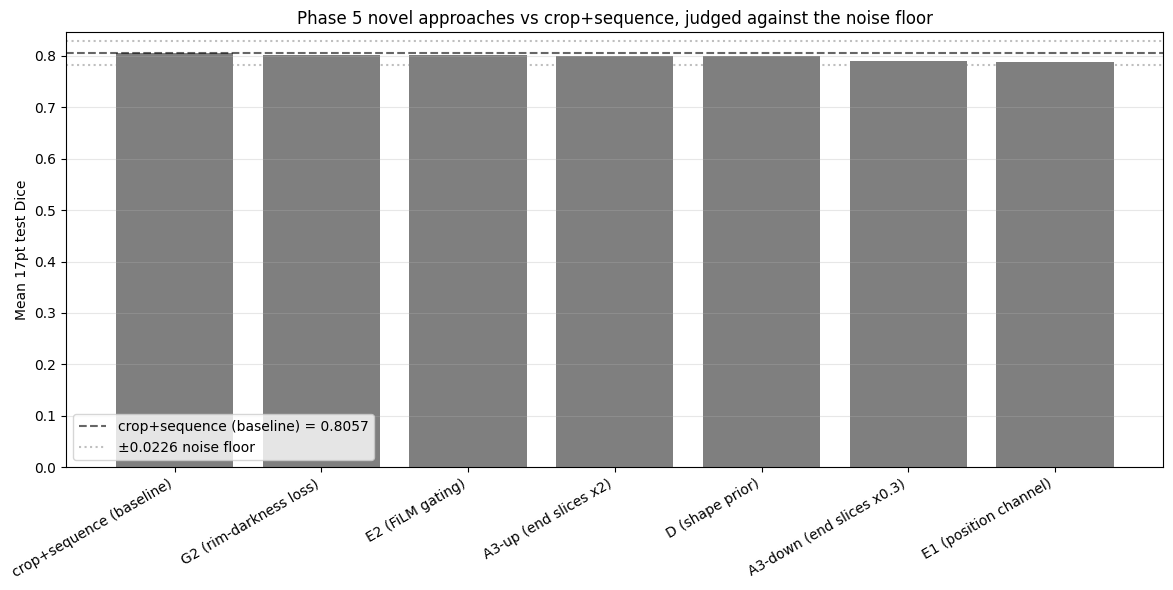

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))
colors = {"real gain": "tab:green", "real loss": "tab:red", "noise / no effect": "tab:gray"}
bar_colors = [colors[d] for d in rank_df["direction"]]
ax.bar(rank_df["run"], rank_df["test_17pt_mean"], color=bar_colors)
ax.axhline(means[baseline_label], linestyle="--", color="black", alpha=0.6, label=f"{baseline_label} = {means[baseline_label]:.4f}")
ax.axhline(means[baseline_label] + NOISE_FLOOR, linestyle=":", color="gray", alpha=0.5)
ax.axhline(means[baseline_label] - NOISE_FLOOR, linestyle=":", color="gray", alpha=0.5, label=f"±{NOISE_FLOOR} noise floor")
ax.set_ylabel("Mean 17pt test Dice")
ax.set_title("Phase 5 novel approaches vs crop+sequence, judged against the noise floor")
ax.set_xticklabels(rank_df["run"], rotation=30, ha="right")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

## Section 4 — PLAIN 2.5D arm (vs `run_v7_replica_seed42`, NOT crop+sequence)

Everything above (Sections 1-3) is built on the **crop+sequence** checkpoint as its base
(`run_v7_crop_sequence`, 2 combined changes already stacked). This section is the
**independent, methodologically clean arm**: each experiment is `finetune_meniscus_v7_replica.py`
+ exactly ONE change, diffed directly against `run_v7_replica_seed42` (val 0.7809, 17pt test
0.7780) -- same discipline as Phase 4's P1/P2/P4.

Two A3 variants exist here and BOTH are kept, not swapped:

- **A3 v1** (`run_2_5d_a3_{up,down}_seed42`) -- the FIRST plain-2.5D A3 attempt. Later found to
  contain a CE-normalisation bug: its per-sample fake-PD cross-entropy divided by pixel count
  instead of by the sum of class weights, making that term ~8.3x too small and silently
  shifting the CE:Dice balance (measured: replica CE=0.000731, v1 CE=0.000088, ratio 0.120x).
  So `A3-up v1` / `A3-down v1` vs replica is NOT a clean one-change comparison.
- **A3 v2** (`run_2_5d_a3v2_{none,up,down}_seed42`) -- the FIX. `finetune_meniscus_v7_replica_a3_v2.py`
  restores the CE match to replica exactly (verified 1.000x at startup, and the script refuses to
  train if that check ever fails). `A3v2-none` is the REQUIRED control (`--variant none`, all
  weights 1.0): per-sample Dice still cannot be made identical to replica's batch Dice (empty-GT
  slices are charged a flat 1.0 either way -- a 14.5x difference measured on a well-fitting model),
  so `A3v2-none` is what isolates that residual. Read `A3v2-up`/`A3v2-down` against `A3v2-none`,
  not against replica directly.

v1's crop+sequence sibling (`finetune_meniscus_v7_crop_seq_a3.py`, used in Sections 1-3 above)
carries the SAME CE bug and was never patched -- so the `A3-up (end slices x2)` /
`A3-down (end slices x0.3)` rows in Sections 1-3 are confounded the same way. No `none` control
exists for that arm.

In [ ]:
RES2 = RES   # same results/ root, different prediction dirs
RUNS2 = RUNS # same segmentation_runs/ root

REPLICA_LABEL = "replica (baseline, seed42)"

RUNS_INFO_2 = {
    REPLICA_LABEL:                          (f"{RES2}/real_pd_predictions_replica_seed42_17pt", f"{RUNS2}/run_v7_replica_seed42"),
    "A3-up v1 [2.5D-plain]":                (f"{RES2}/real_pd_predictions_2_5d_a3_up_17pt",      f"{RUNS2}/run_2_5d_a3_up_seed42"),
    "A3-down v1 [2.5D-plain]":              (f"{RES2}/real_pd_predictions_2_5d_a3_down_17pt",    f"{RUNS2}/run_2_5d_a3_down_seed42"),
    "A3v2-none [2.5D-plain] (control)":     (f"{RES2}/real_pd_predictions_2_5d_a3v2_none_17pt",  f"{RUNS2}/run_2_5d_a3v2_none_seed42"),
    "A3v2-up [2.5D-plain, CE-fixed]":       (f"{RES2}/real_pd_predictions_2_5d_a3v2_up_17pt",    f"{RUNS2}/run_2_5d_a3v2_up_seed42"),
    "A3v2-down [2.5D-plain, CE-fixed]":     (f"{RES2}/real_pd_predictions_2_5d_a3v2_down_17pt",  f"{RUNS2}/run_2_5d_a3v2_down_seed42"),
    "E1 [2.5D-plain] (position channel)":   (f"{RES2}/real_pd_predictions_2_5d_e1_17pt",         f"{RUNS2}/run_2_5d_e1_seed42"),
    "E2 [2.5D-plain] (FiLM gating)":        (f"{RES2}/real_pd_predictions_2_5d_e2_17pt",         f"{RUNS2}/run_2_5d_e2_seed42"),
    "G2 [2.5D-plain] (rim-darkness loss)":  (f"{RES2}/real_pd_predictions_2_5d_g2_17pt",         f"{RUNS2}/run_2_5d_g2_seed42"),
    "D [2.5D-plain] (shape prior)":         (f"{RES2}/real_pd_predictions_2_5d_d_17pt",          f"{RUNS2}/run_2_5d_d_lamauto_seed42"),
}
# Paths verified 2026-09-22 directly against the CKPT=/OUT_DIR= lines actually written into
# each slurm_files/infer_2_5d_*_17pt.sh / finetune_2_5d_*.sh job file -- not retyped from memory.

preds_by_run_2 = {}
for label, (pred_dir, _) in RUNS_INFO_2.items():
    d = patients_in_dir(pred_dir) if os.path.isdir(pred_dir) else {}
    preds_by_run_2[label] = d
    status = f"{len(d)}/{len(ALL_PATIENTS)}" if d else "NOT FOUND -- pull results down / run inference first"
    print(f"{label:<36}: {status}")

In [ ]:
rows2 = []
for pid in ALL_PATIENTS:
    if pid not in gt_masks:
        continue
    gt_bin = load_nrrd_binary(gt_masks[pid])
    row = {"patient": pid, "cohort": "D1" if pid in D1_PATIENTS else "new"}
    for label, preds in preds_by_run_2.items():
        if pid in preds:
            pred = load_vol(preds[pid])
            row[label] = dice_score(merge_meniscus(pred), gt_bin)
        else:
            row[label] = float("nan")
    rows2.append(row)

df2 = pd.DataFrame(rows2)
means2 = df2[list(RUNS_INFO_2.keys())].mean()
print("MEAN 17pt Dice per run (plain 2.5D arm):")
print(means2.round(4).to_string())
df2

In [ ]:
# Control check: replica's OWN 17pt inference here should reproduce its already-known
# result (0.7780) before trusting the plain-2.5D columns -- same discipline as cell 8's
# crop+sequence control check above.
if REPLICA_LABEL in means2.index and not np.isnan(means2[REPLICA_LABEL]):
    print(f"{REPLICA_LABEL} 17pt mean: {means2[REPLICA_LABEL]:.4f}  (reference: 0.7780)")
    if abs(means2[REPLICA_LABEL] - 0.7780) > 1e-3:
        print("  WARNING: does not match the known reference -- check GT/pred alignment "
              "before trusting any other column in this section.")

## Section 5 — Validation Dice, plain 2.5D arm (2 real-val patients, from `history.csv`)

In [ ]:
val_rows_2 = []
for label, (_, run_dir) in RUNS_INFO_2.items():
    info = best_epoch_val_dice(os.path.join(run_dir, "history.csv"))
    if info is None:
        print(f"{label:<36}: history.csv not found under {run_dir}")
        continue
    val_rows_2.append({"run": label, **info})

val_df2 = pd.DataFrame(val_rows_2)
val_df2

## Section 6 — Comparative ranking, plain 2.5D arm (17pt test Dice vs REPLICA, vs noise floor)

Baseline here is `replica (baseline, seed42)`, NOT crop+sequence -- this arm answers "does X
help the actual replica recipe in isolation," the same question Phase 4's P1/P2/P4 asked.
`A3v2-up`/`A3v2-down` are ALSO shown against `A3v2-none` (the CE-fix control) as a second,
more precise read, since per-sample-vs-batch Dice still differs from replica's own Dice by a
margin larger than the noise floor (see Section 4's note).

In [ ]:
rank_rows_2 = []
for label in RUNS_INFO_2:
    if label not in means2.index or np.isnan(means2[label]):
        continue
    delta = means2[label] - means2[REPLICA_LABEL]
    rank_rows_2.append({
        "run": label,
        "test_17pt_mean": round(means2[label], 4),
        "delta_vs_replica": round(delta, 4),
        "above_noise_floor": abs(delta) > NOISE_FLOOR,
        "direction": ("real gain" if delta > NOISE_FLOOR else
                      "real loss" if delta < -NOISE_FLOOR else
                      "noise / no effect"),
    })

rank_df2 = pd.DataFrame(rank_rows_2).sort_values("test_17pt_mean", ascending=False).reset_index(drop=True)
print(f"Baseline: {REPLICA_LABEL} = {means2[REPLICA_LABEL]:.4f}   |   noise floor = ±{NOISE_FLOOR}")
rank_df2

In [ ]:
a3v2_control_label = "A3v2-none [2.5D-plain] (control)"
if a3v2_control_label in means2.index and not np.isnan(means2[a3v2_control_label]):
    print(f"Secondary read -- A3v2 up/down vs the CE-fix control ({a3v2_control_label} = {means2[a3v2_control_label]:.4f}):")
    for label in ["A3v2-up [2.5D-plain, CE-fixed]", "A3v2-down [2.5D-plain, CE-fixed]"]:
        if label in means2.index and not np.isnan(means2[label]):
            d = means2[label] - means2[a3v2_control_label]
            direction = ("real gain" if d > NOISE_FLOOR else "real loss" if d < -NOISE_FLOOR else "noise / no effect")
            print(f"  {label:<36}: {means2[label]:.4f}  (delta vs control {d:+.4f}, {direction})")

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
colors = {"real gain": "tab:green", "real loss": "tab:red", "noise / no effect": "tab:gray"}
bar_colors = [colors[d] for d in rank_df2["direction"]]
ax.bar(rank_df2["run"], rank_df2["test_17pt_mean"], color=bar_colors)
ax.axhline(means2[REPLICA_LABEL], linestyle="--", color="black", alpha=0.6, label=f"{REPLICA_LABEL} = {means2[REPLICA_LABEL]:.4f}")
ax.axhline(means2[REPLICA_LABEL] + NOISE_FLOOR, linestyle=":", color="gray", alpha=0.5)
ax.axhline(means2[REPLICA_LABEL] - NOISE_FLOOR, linestyle=":", color="gray", alpha=0.5, label=f"±{NOISE_FLOOR} noise floor")
ax.set_ylabel("Mean 17pt test Dice")
ax.set_title("Plain 2.5D arm vs replica, judged against the noise floor")
ax.set_xticklabels(rank_df2["run"], rotation=30, ha="right")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()